<div dir="rtl" style="direction: rtl; unicode-bidi: isolate-override; text-align: right;">

<h1>بخش اول - سوال ۱: مدل آستانه خطی <span dir="ltr">(Linear Threshold)</span> روی شبکه  <span dir="ltr">Higgs Twitter</span></h1>

<div dir="rtl" style="direction: rtl; unicode-bidi: isolate-override; text-align: right;">
در این بخش، انتشار رفتار یا همان اطلاعات را با مدل آستانه خطی شبیه‌سازی می‌کنیم.
آستانه فعال‌سازی ابتدا ۰۵٪ در نظر گرفته می‌شود و سپس با افزایش آستانه، تغییرات سرعت و گستره انتشار مقایسه می‌گردد.


<h3>فرض‌ها</h3>
<ul style="direction: rtl; unicode-bidi: isolate-override; text-align: right;">
  <li>گراف جهت‌دار است. از صفحه kaggle دیتاست این بررسی را انجام دادم.</li>
  <li>
    یال <span dir="ltr">u → v</span> یعنی <span dir="ltr">u</span> می‌تواند روی <span dir="ltr">v</span> اثر بگذارد؛
    بنابراین معیار فعال‌سازی برای هر گره، همسایه‌های ورودی <span dir="ltr">(in-neighbors)</span> هستند.
  </li>
  <li>
    گره‌های فعال اولیه <span dir="ltr">(seed)</span> به تعداد <span dir="ltr">k</span> از بین گره‌های با بیشترین
    <span dir="ltr">out-degree</span> انتخاب می‌شوند. از آنجایی که شبکه بسیار بزرگ است و تعداد گره‌های اولیه به طور مشخص ذکر نشده بود، من مقدار ۱٫۰۰۰ را با توجه به اندازه شبکه که در حدود ۴۵۰٫۰۰۰ گره است، انتخاب کردم. شاید تعداد گره‌های فعال اولیه در نگاه نخست، زیاد به نظر برسد، ولی برای یک شبیه‌سازی مطلوب و با توجه به اندازه بزرگ شبکه، انتخاب کمتر از نیم درصد گره‌ها زیاد از حد نیست.
  </li>
</ul>

</div>


In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gzip
from itertools import combinations

In [3]:
# ---- Config ----
EDGE_PATH = r"Data Sets/Intermediate/Twitter Higgs Dataset (SNAP)/higgs-social_network.edgelist.gz"
DIRECTED = True

# Read gzip edge list. Many SNAP edgelists are whitespace-separated and headerless.
df = pd.read_csv(
    EDGE_PATH,
    sep=r"\s+",
    header=None,
    compression="gzip",
    comment="#"
)

# We only need the first two columns as src/dst.
if df.shape[1] < 2:
    raise ValueError("Edge list must have at least 2 columns (src, dst).")

edges = df.iloc[:, :2].dropna()
edges.columns = ["src", "dst"]

G = nx.DiGraph() if DIRECTED else nx.Graph()
G.add_edges_from(edges.itertuples(index=False, name=None))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Example edges:", list(G.edges())[:5])


Nodes: 456626
Edges: 14855842
Example edges: [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]


In [4]:
def choose_seeds_top_out_degree(G: nx.DiGraph, k: int = 20):
    # With u->v meaning u influences v, high out-degree nodes are strong spreaders.
    deg = G.out_degree() if G.is_directed() else G.degree()
    ranked = sorted(deg, key=lambda x: x[1], reverse=True)
    return [n for n, _ in ranked[:k]]

k = 1000
seeds = choose_seeds_top_out_degree(G, k=k)

print("Seed count:", len(seeds))
print("First seeds:", seeds[:10])


Seed count: 1000
First seeds: [13115, 49180, 50338, 1984, 3628, 16092, 5226, 26150, 21386, 7643]


In [5]:
def linear_threshold_cascade_in_neighbors(G: nx.DiGraph, seeds, theta: float = 0.5, max_steps: int = 10000):
    """
    Linear Threshold cascade using in-neighbors as influencers.
    Node v activates if (# active in-neighbors of v) / (in-degree of v) >= theta.
    """
    active = set(seeds)

    # Precompute in-neighbor lists for speed.
    in_nbrs = {v: list(G.predecessors(v)) for v in G.nodes()}

    active_counts = [len(active)]
    new_activated_counts = []

    # Track inactive nodes to avoid scanning active ones repeatedly.
    inactive = set(G.nodes()) - active

    for _step in range(1, max_steps + 1):
        newly_active = set()

        for v in list(inactive):
            nbrs = in_nbrs[v]
            if not nbrs:
                continue

            # Count active in-neighbors.
            act = sum((u in active) for u in nbrs)
            if act / len(nbrs) >= theta:
                newly_active.add(v)

        if not newly_active:
            break

        active |= newly_active
        inactive -= newly_active

        new_activated_counts.append(len(newly_active))
        active_counts.append(len(active))

    return active_counts, new_activated_counts


Iterations (until stop): 4
Final active nodes: 5173 out of 456626


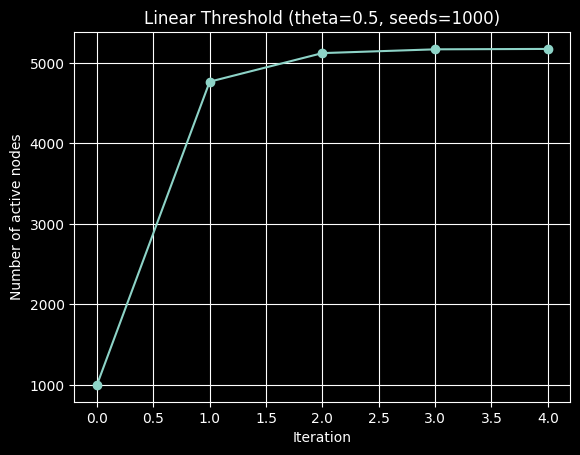

In [6]:
theta = 0.5
active_counts, new_counts = linear_threshold_cascade_in_neighbors(G, seeds, theta=theta)

print("Iterations (until stop):", len(active_counts) - 1)
print("Final active nodes:", active_counts[-1], "out of", G.number_of_nodes())

plt.figure()
plt.plot(range(len(active_counts)), active_counts, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Number of active nodes")
plt.title(f"Linear Threshold (theta={theta}, seeds={len(seeds)})")
plt.grid(True)
plt.show()


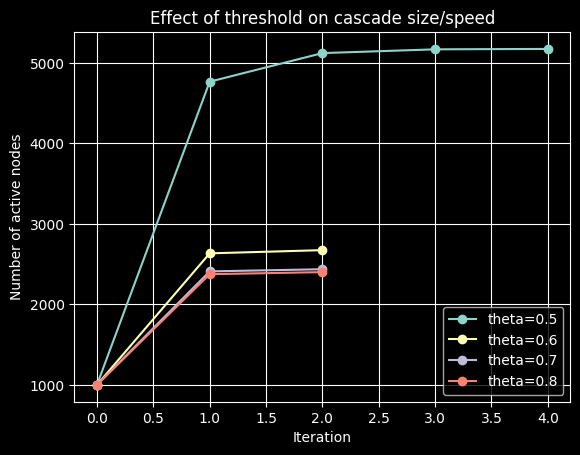

,theta,steps_to_stop,final_active
0,0.5,4,5173
1,0.6,2,2674
2,0.7,2,2437
3,0.8,2,2401


In [7]:
thetas = [0.5, 0.6, 0.7, 0.8]
summary = []

plt.figure()
for th in thetas:
    a_counts, _ = linear_threshold_cascade_in_neighbors(G, seeds, theta=th)
    summary.append({
        "theta": th,
        "steps_to_stop": len(a_counts) - 1,
        "final_active": a_counts[-1]
    })
    plt.plot(range(len(a_counts)), a_counts, marker="o", label=f"theta={th}")

plt.xlabel("Iteration")
plt.ylabel("Number of active nodes")
plt.title("Effect of threshold on cascade size/speed")
plt.grid(True)
plt.legend()
plt.show()

summary_df = pd.DataFrame(summary)
summary_df


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate;">
  <h2>نتیجه‌گیری (مدل آستانه خطی)</h2>

  <ul style="direction: rtl; text-align: right; unicode-bidi: isolate; padding-right: 1.2em; padding-left: 0;">
    <li>
      &rlm;برای آستانه ۰.۵، نمودار تعداد گره‌های فعال در هر مرحله رسم گردیده و تعداد نهایی گره‌های فعال گزارش شده است.
    </li>
    <li>
      &rlm;با افزایش آستانه (مثلاً ۰.۶، ۰.۷، ۰.۸) معمولاً فعال‌سازی سخت‌تر می‌شود و تعداد نهایی فعال‌ها کاهش می‌یابد و انتشار زودتر متوقف می‌شود. این یک امر طبیعی و بدیهی‌ست که با افزایش درصد گره‌های فعال برای فعال‌سازی یک گره مشخص یا همان شاخص تتا، سرعت فعال‌سازی کاهش یابد؛ اما باید توجه داشت که به طور کلی انتشار در روش LT بسیار ناگهانی‌ست و این تفاوت سرعت در مثالی که آوورده شده در حد یک تکرار فرق دارد. من با مقدار ۱۰٫۰۰۰ هم تست کردم و در آن حالت به دلیل این‌که انتشار کامل تعداد بسیار بیشتری تکرار طول می‌کشید (به طور مثال ۵۰ تکرار برای آستانه نیم) تفاوت سرعت مشهودتری قابل مشاهده بود.
    </li>
    <li>
      &rlm;جدول مقایسه شامل «تعداد گام‌ها تا توقف» و «تعداد نهایی فعال‌ها» برای هر آستانه ارائه گردیده است.
    </li>
  </ul>
</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>بخش اول - سوال ۲: مدل آبشار مستقل <span dir="ltr">(Independent Cascade)</span> روی شبکه <span dir="ltr">Higgs Twitter</span></h1>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در مدل <span dir="ltr">IC</span>، هر گره‌ای که تازه فعال می‌شود دقیقاً <b>یک‌بار</b> تلاش می‌کند همسایه‌های (خروجی) غیرفعالِ خود را با احتمال
<span dir="ltr">p = 0.1</span> فعال کند. این فرآیند به‌صورت گام‌به‌گام ادامه می‌یابد تا زمانی که در یک گام هیچ فعال‌سازی                                                                                          جدیدی رخ ندهد.
از آن‌جا که مدل <span dir="ltr">IC</span> تصادفی است، شبیه‌سازی را چندین بار تکرار می‌کنیم و سپس:
</p>

<ul>
  <li>میانگین اندازه نفوذ (تعداد کل گره‌های فعال‌شده در انتها) را گزارش می‌کنیم.</li>
  <li>نمودار رشد (تعداد فعال‌ها برحسب گام) را رسم می‌کنیم (میانگین روی تکرارها).</li>
  <li>تعداد گام‌های لازم تا توقف را نیز بررسی می‌کنیم.</li>
</ul>

</div>


In [8]:
def independent_cascade_out_neighbors(
    G: nx.Graph,
    seeds,
    p: float = 0.1,
    max_steps: int = 10_000,
    rng: np.random.Generator | None = None,
):
    """
    Independent Cascade (IC) model:
    - When a node becomes active, it gets exactly ONE chance to activate each inactive neighbor.
    - For directed graphs, we treat edges u->v as "u can influence v" and use successors(u).
    - Synchronous stepping: activations from step t form the newly-active set for step t+1.

    Returns:
        active_counts: cumulative number of active nodes per step (including step 0)
        new_counts: number of newly activated nodes per step (including step 0)
    """
    if rng is None:
        rng = np.random.default_rng()

    # Use set for O(1) membership checks
    active = set(seeds)
    newly_active = set(seeds)

    active_counts = [len(active)]
    new_counts = [len(newly_active)]

    # Choose neighbor iterator based on directedness
    is_dir = G.is_directed()
    nbrs = (lambda u: G.successors(u)) if is_dir else (lambda u: G.neighbors(u))

    for _ in range(max_steps):
        if not newly_active:
            break

        next_new = set()

        # Each newly active node attempts to activate each currently inactive neighbor once
        for u in newly_active:
            for v in nbrs(u):
                if v in active:
                    continue
                if rng.random() < p:
                    next_new.add(v)

        newly_active = next_new
        active |= newly_active

        active_counts.append(len(active))
        new_counts.append(len(newly_active))

    return active_counts, new_counts


In [9]:
# ---- IC Experiment Config ----
p = 0.10
num_runs = 30
seed_base = 12345


seeds_ic = seeds  # reuse LT seeds by default

final_sizes = []
steps_to_stop = []
curves = []

for r in range(num_runs):
    rng = np.random.default_rng(seed_base + r)

    active_counts, _ = independent_cascade_out_neighbors(
        G, seeds_ic, p=p, max_steps=10_000, rng=rng
    )

    curves.append(active_counts)
    final_sizes.append(active_counts[-1])
    steps_to_stop.append(len(active_counts) - 1)

final_sizes = np.array(final_sizes)
steps_to_stop = np.array(steps_to_stop)

print(f"IC with p={p}, runs={num_runs}")
print("Mean final active:", final_sizes.mean())
print("Std final active:", final_sizes.std(ddof=1))
print("Min/Max final active:", final_sizes.min(), final_sizes.max())
print("Mean steps until stop:", steps_to_stop.mean())


IC with p=0.1, runs=30
Mean final active: 160247.16666666666
Std final active: 316.91183189556415
Min/Max final active: 159583 160818
Mean steps until stop: 17.133333333333333


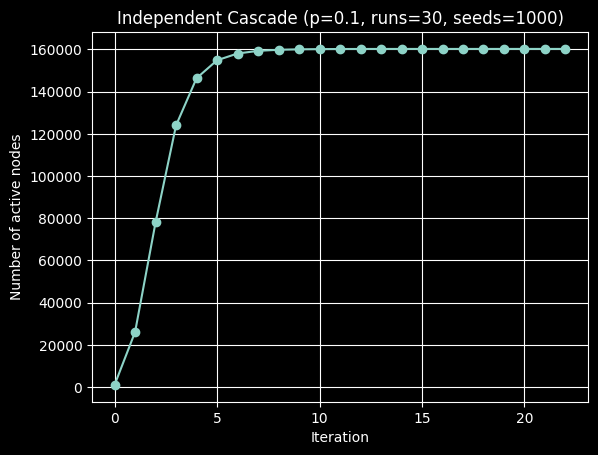

In [10]:
# ---- Mean growth curve (pad each run to same length using last value) ----
max_len = max(len(c) for c in curves)
mat = np.zeros((num_runs, max_len), dtype=float)

for i, c in enumerate(curves):
    mat[i, :len(c)] = c
    mat[i, len(c):] = c[-1]  # pad with final size

mean_curve = mat.mean(axis=0)

# ---- Plot: same style as your LT plots ----
plt.figure()
plt.plot(range(len(mean_curve)), mean_curve, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Number of active nodes")
plt.title(f"Independent Cascade (p={p}, runs={num_runs}, seeds={len(seeds_ic)})")
plt.grid(True)
plt.show()

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>تحلیل و مقایسه با مدل آستانه خطی <span dir="ltr">(LT)</span></h2>

<ul>
  <li>
    <b>تصادفی بودن:</b> در <span dir="ltr">IC</span> نتیجه هر اجرا می‌تواند متفاوت باشد؛ بنابراین «میانگین» (به همراه انحراف معیار) معیار مناسب‌تری است.
    در مقابل، <span dir="ltr">LT</span> (با آستانه ثابت و بذرهای ثابت) معمولاً رفتاری مشخص‌تری دارد و به این دلیل در اکثر موارد نیاز به شبیه‌سازی‌های متعدد ندارد.
  </li>

  <li>
    <b>سرعت انتشار:</b> در <span dir="ltr">IC</span> ممکن است انتشار در برخی اجراها سریع و در برخی کند باشد، چون فعال‌سازی‌ها وابسته به احتمال هستند.
    در <span dir="ltr">LT</span> اگر هسته اولیه در نواحی متراکم باشد، ممکن است با چند گام جهش‌های بزرگ رخ دهد (وابسته به آستانه). توجه شود همان‌طور که در مورد قبل ذکر کردم، انتخاب تعداد گره‌های فعال اولیه بیشتر (برای ۱۰٫۰۰۰ امتحان شد) می‌تواند تکرارهای روش LT را افزایش دهد و به ظاهر سرعت اتمام فرآیندش را کاهش دهد؛ اما در عمل به طور معمول روش LT با سرعت بسیار بیشتری برخلاف این روش به ماکسیمم تعداد گره‌های فعال می‌رسد.
  </li>

  <li>
    <b>اندازه نفوذ یا همان انتشار:</b> در <span dir="ltr">IC</span> با افزایش <span dir="ltr">p</span> معمولاً نفوذ نهایی و همچنین احتمال عبور از مرزهای ساختاری شبکه افزایش می‌یابد.
    در <span dir="ltr">LT</span> افزایش آستانه معمولاً نفوذ نهایی را کم کرده و انتشار را دشوارتر می‌کند.
  </li>
</ul>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در این بخش، نمودار رشدِ میانگین و همچنین پراکندگی نتایج روی چند اجرا کمک می‌کند اثرِ تصادفی بودنِ <span dir="ltr">IC</span> را بهتر مشاهده کنیم.
</p>

</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>بخش دوم - سؤال ۱: مدل باراباسی–آلبرت <span dir="ltr">(Barabási–Albert)</span> و قانون توانی</h1>

<h2>ایده و الگوریتم <span dir="ltr">Preferential Attachment</span></h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در مدل <span dir="ltr">Barabási–Albert</span> شبکه به‌صورت «رشد همراه با اتصال امتیازی» ساخته می‌شود:
</p>

<ol>
  <li>با یک گراف اولیه کوچک شروع می‌کنیم (در پیاده‌سازی‌های استاندارد معمولاً یک کلیک با اندازه <span dir="ltr">m</span>).</li>
  <li>
    سپس در هر مرحله یک گره جدید اضافه می‌کنیم و آن را با <span dir="ltr">m</span> یال به گره‌های قبلی متصل می‌کنیم.
  </li>
  <li>
    انتخاب هر گره مقصد تصادفی است ولی با احتمال متناسب با درجه آن انجام می‌شود:
    <span dir="ltr">P(i) = deg(i) / sum_j deg(j)</span>
    (یعنی «پولدارها پولدارتر می‌شوند»).
  </li>
</ol>

<h2>استخراج نمای قانون توانی</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
اگر توزیع درجه قانون توانی داشته باشد، تقریباً داریم:
<span dir="ltr">P(k) ∝ k^{-γ}</span>.
با گرفتن لگاریتم:
<span dir="ltr">log P(k) = a - γ log k</span>
پس با رسم نمودار <span dir="ltr">log-log</span> و انجام برازش خطی روی داده‌های لگاریتمی، شیب خط تقریباً برابر
<span dir="ltr">-γ</span>
می‌شود و می‌توانیم نمای <span dir="ltr">γ</span> را گزارش کنیم.
</p>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در این قسمت:
</p>
<ul>
  <li>گراف <span dir="ltr">BA</span> با <span dir="ltr">n=5000</span> و <span dir="ltr">m=3</span> می‌سازیم.</li>
  <li>توزیع درجه <span dir="ltr">P(k)</span> را محاسبه می‌کنیم.</li>
  <li>نمودار <span dir="ltr">log-log</span> را رسم می‌کنیم و برازش خطی را انجام می‌دهیم.</li>
</ul>

</div>


BA graph: n=5000, m=3
Estimated exponent gamma ≈ 1.9009
Linear fit (log space): log10 P(k) = -0.0447 + (-1.9009) log10 k
R^2 (log space) = 0.8563


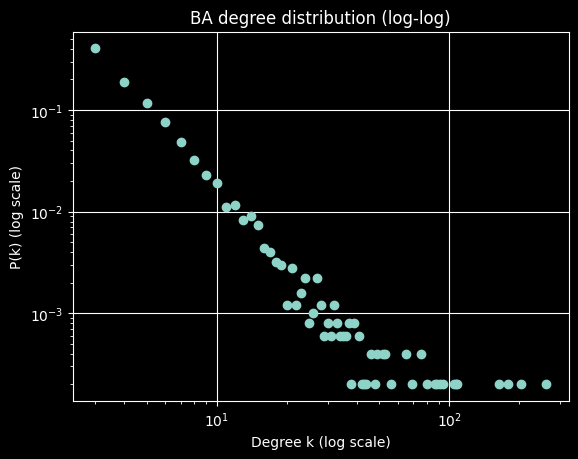

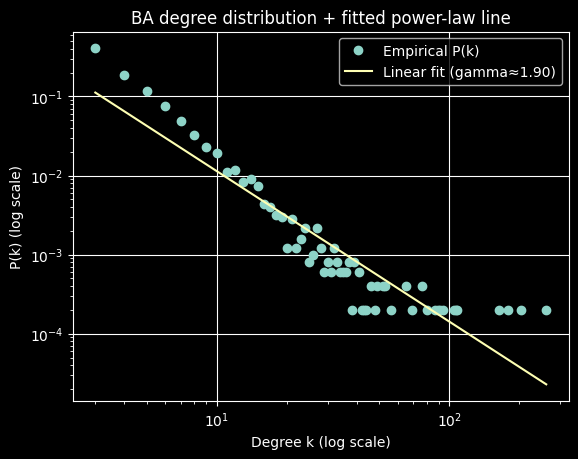

,n,m,gamma_hat,slope_b,intercept_a,R2_log_space
0,5000,3,1.900867,-1.900867,-0.044706,0.856333


In [11]:
# -----------------------------
# Q2 - Part 1: BA graph + degree distribution (log-log) + exponent estimation
# -----------------------------

# --- Parameters requested by the assignment ---
n = 5000
m = 3
random_seed = 42

# 1) Generate Barabási–Albert graph using preferential attachment
# NetworkX BA model: start from a small initial graph and add nodes one-by-one,
# each new node attaches to m existing nodes with probability proportional to their degree.
G_ba = nx.barabasi_albert_graph(n=n, m=m, seed=random_seed)

# 2) Compute degree distribution P(k)
degrees = np.array([d for _, d in G_ba.degree()])

# Count how many nodes have each degree k
# (Only keep degrees that actually appear)
k_vals, counts = np.unique(degrees, return_counts=True)

# Convert counts to probabilities: P(k) = count(k) / n
pk = counts / n

# 3) Fit a line on log-log data: log10(P(k)) = a + b*log10(k)
# The power-law exponent is gamma = -b
# For BA with m=3, the minimum degree is typically >= 3, so we can fit from k >= m.
fit_mask = (k_vals >= m) & (pk > 0)

log_k = np.log10(k_vals[fit_mask])
log_pk = np.log10(pk[fit_mask])

# Linear regression via polyfit: log_pk ≈ b*log_k + a
b, a = np.polyfit(log_k, log_pk, 1)
gamma_hat = -b

# R^2 (how well the line explains variance in log space)
log_pk_pred = b * log_k + a
ss_res = np.sum((log_pk - log_pk_pred) ** 2)
ss_tot = np.sum((log_pk - np.mean(log_pk)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

print(f"BA graph: n={n}, m={m}")
print(f"Estimated exponent gamma ≈ {gamma_hat:.4f}")
print(f"Linear fit (log space): log10 P(k) = {a:.4f} + ({b:.4f}) log10 k")
print(f"R^2 (log space) = {r2:.4f}")

# 4) Plot degree distribution on log-log scale (same plot style as your previous ones)
plt.figure()
plt.plot(k_vals, pk, marker="o", linestyle="")  # points (no connecting lines)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("P(k) (log scale)")
plt.title("BA degree distribution (log-log)")
plt.grid(True)
plt.show()

# 5) Optional: show fitted line on the same log-log plot (still in your style)
# Create a smooth range in log space for the fit line
k_fit_line = np.unique(k_vals[fit_mask])
pk_fit_line = 10 ** (a + b * np.log10(k_fit_line))

plt.figure()
plt.plot(k_vals, pk, marker="o", linestyle="", label="Empirical P(k)")
plt.plot(k_fit_line, pk_fit_line, label=f"Linear fit (gamma≈{gamma_hat:.2f})")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("P(k) (log scale)")
plt.title("BA degree distribution + fitted power-law line")
plt.grid(True)
plt.legend()
plt.show()

# Small summary table (useful for the report)
ba_summary_df = pd.DataFrame([{
    "n": n,
    "m": m,
    "gamma_hat": gamma_hat,
    "slope_b": b,
    "intercept_a": a,
    "R2_log_space": r2
}])
ba_summary_df


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
همان‌طور که مشاهده می‌شود، در نمودار log-log توزیع درجات به صورت خطی است. البته در قسمت پایینی نمودار، نویزهایی دیده می‌شود که باعث شده برازش خط و همچنین خطی‌بودن این توزیع درجه بی‌نقص نباشد که خاصیت توزیع درجه توانی‌ست. مقدار شیب خط ۹.۱- است که همان توان توزیع درجه در فرمول (گاما) است. همچنین امتیاز <span dir="ltr">R²</span> بالا نشان‌دهنده برازش مطلوب خط بر روی این نمودار است که دلیل محکم دیگری بر توزیع توانی می‌باشد.

</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>بخش دوم — سؤال ۲ (قسمت دوم): توزیع درجه در شبکه‌ی واقعی <span dir="ltr">DisGeNET</span></h1>

<h2>روش/الگوریتمی که استفاده می‌کنیم</h2>
<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در این قسمت هدف این است که توزیع درجه‌ی شبکه‌ی واقعی را محاسبه و در دو حالتِ
<span dir="ltr">linear</span>
و
<span dir="ltr">log-log</span>
ترسیم کنیم و سپس (مثل بخش قبل) یک برازش خطی روی داده‌های لگاریتمی انجام دهیم تا نمای قانون توانی را تخمین بزنیم.
</p>

<ol>
  <li>خواندن فایل یال‌ها و ساخت گراف (در این‌جا گراف را <b>بدون‌جهت</b> در نظر می‌گیریم).</li>
  <li>محاسبه درجه همه گره‌ها و تبدیل آن به توزیع <span dir="ltr">P(k)</span>.</li>
  <li>رسم <span dir="ltr">P(k)</span> در مقیاس معمولی و سپس در مقیاس <span dir="ltr">log-log</span>.</li>
  <li>
    انجام برازش خطی روی
    <span dir="ltr">log10(P(k))</span>
    بر حسب
    <span dir="ltr">log10(k)</span>
    و گزارش
    <span dir="ltr">γ</span>
    از رابطه
    <span dir="ltr">P(k) ∝ k^{-γ}</span>.
  </li>
</ol>

</div>


Columns: ['geneId', 'geneSymbol', 'geneName', 'diseaseId', 'diseaseName', 'score', 'NumberOfPubmeds', 'associationType', 'source']
Using endpoints: geneId -> diseaseId
DisGeNET graph loaded.
Nodes: 31800
Edges: 429111
Estimated exponent gamma ≈ 1.2942
Linear fit (log space): log10 P(k) = -0.7578 + (-1.2942) log10 k
R^2 (log space) = 0.8363


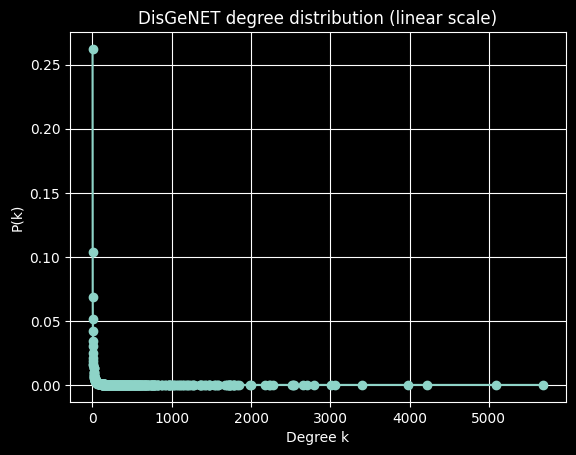

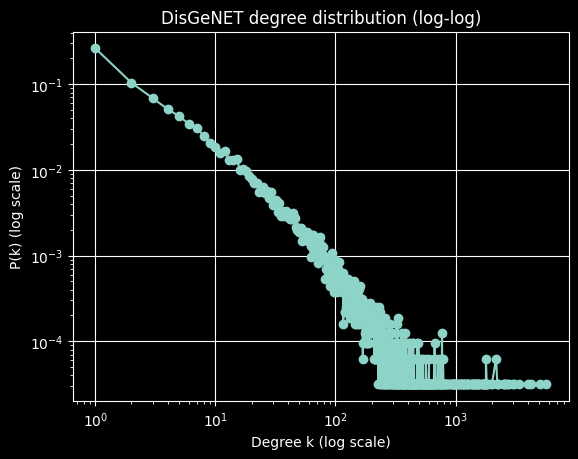

 nodes  edges  k_min_fit  gamma_hat   slope_b  intercept_a  R2_log_space
 31800 429111          1   1.294219 -1.294219    -0.757842      0.836303


In [12]:
# -----------------------------
# Q2 - Part 2: DisGeNET (.txt.gz) degree distribution (linear + log-log) + exponent estimation
# -----------------------------

# ---- 1) File path (your file) ----
path_disgenet = r"Data Sets/Intermediate/DisGeNET/all_gene_disease_associations.txt.gz"

# DisGeNET "all_gene_disease_associations" is typically TSV with a header row
sep = "\t"

# ---- 2) Read preview to confirm columns ----
preview = pd.read_csv(
    path_disgenet,
    sep=sep,
    compression="gzip",
    comment="#",
    nrows=5,
    low_memory=False
)

print("Columns:", list(preview.columns))

# We will use geneId -> diseaseId edges (as your preview showed)
src_col, dst_col = "geneId", "diseaseId"
if not {src_col, dst_col}.issubset(preview.columns):
    raise ValueError(
        f"Expected columns '{src_col}' and '{dst_col}' not found. "
        f"Available columns: {list(preview.columns)}"
    )

print(f"Using endpoints: {src_col} -> {dst_col}")

# ---- 3) Build graph in chunks (memory-safe) ----
G_dis = nx.Graph()

chunk_size = 300_000  # safer in PyCharm; you can raise if you want

reader = pd.read_csv(
    path_disgenet,
    sep=sep,
    compression="gzip",
    comment="#",
    usecols=[src_col, dst_col],
    dtype=str,
    chunksize=chunk_size,
    low_memory=False
)

for chunk in reader:
    # Drop rows with missing endpoints
    chunk = chunk.dropna(subset=[src_col, dst_col])

    # Prefix nodes to avoid collisions between gene IDs and disease IDs
    genes = "G:" + chunk[src_col].astype(str)
    dises = "D:" + chunk[dst_col].astype(str)

    # Add edges in bulk
    G_dis.add_edges_from(zip(genes, dises))

# Remove self-loops (usually none, but safe)
G_dis.remove_edges_from(nx.selfloop_edges(G_dis))

print("DisGeNET graph loaded.")
print("Nodes:", G_dis.number_of_nodes())
print("Edges:", G_dis.number_of_edges())

# ---- 4) Degree distribution P(k) ----
degrees = np.fromiter((d for _, d in G_dis.degree()), dtype=int)
k_vals, counts = np.unique(degrees, return_counts=True)
pk = counts / G_dis.number_of_nodes()

# ---- 5) Fit power-law exponent in log space ----
# Avoid k=0 (log undefined). In this graph degrees should start at >=1.
k_min = 1
fit_mask = (k_vals >= k_min) & (pk > 0)

log_k = np.log10(k_vals[fit_mask])
log_pk = np.log10(pk[fit_mask])

# Linear regression: log10 P(k) ≈ a + b log10 k  =>  gamma ≈ -b
b, a = np.polyfit(log_k, log_pk, 1)
gamma_hat = -b

# R^2 in log space
log_pk_pred = b * log_k + a
ss_res = np.sum((log_pk - log_pk_pred) ** 2)
ss_tot = np.sum((log_pk - np.mean(log_pk)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

print(f"Estimated exponent gamma ≈ {gamma_hat:.4f}")
print(f"Linear fit (log space): log10 P(k) = {a:.4f} + ({b:.4f}) log10 k")
print(f"R^2 (log space) = {r2:.4f}")

# ---- 6) Plots (same style as your previous plots) ----

# 6a) Linear scale
plt.figure()
plt.plot(k_vals, pk, marker="o")
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("DisGeNET degree distribution (linear scale)")
plt.grid(True)
plt.show()

# 6b) Log-log scale
plt.figure()
plt.plot(k_vals, pk, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("P(k) (log scale)")
plt.title("DisGeNET degree distribution (log-log)")
plt.grid(True)
plt.show()

# ---- 7) Summary (print instead of returning a DataFrame as last output, to avoid hiding plots in PyCharm) ----
disgenet_summary_df = pd.DataFrame([{
    "nodes": G_dis.number_of_nodes(),
    "edges": G_dis.number_of_edges(),
    "k_min_fit": k_min,
    "gamma_hat": gamma_hat,
    "slope_b": b,
    "intercept_a": a,
    "R2_log_space": r2
}])

print(disgenet_summary_df.to_string(index=False))


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>نتیجه‌گیری (بر اساس خروجی کد و شکل کشیده‌شده)</h2>

<ul>
  <li>
    در خروجی چاپ‌شده، مقدار
    <span dir="ltr">γ</span>
    (نمای قانون توانی تخمین‌زده‌شده) و همچنین
    <span dir="ltr">R²</span>
    در فضای لگاریتمی و دقیقا مانند قسمت قبل گزارش شده است.
  </li>
  <li>
    اگر مقدار
    <span dir="ltr">R²</span>
    نسبتاً بالا باشد و نقاط در نمودار <span dir="ltr">log-log</span> تقریباً روند خطی داشته باشند (که این‌طور نیز هست)، این می‌تواند نشانه دم‌سنگین (heavy-tail) بودن توزیع درجه باشد.
  </li>
  <li>
    در صورت نیاز می‌توان
    <span dir="ltr">k_min</span>
    را بزرگ‌تر گرفت (مثلاً ۲ یا ۳) تا اثر نویز درجات بسیار کوچک روی برازش کم‌تر شود.
  </li>
</ul>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
شباهتِ کلی نمودارهای <span dir="ltr">BA</span> و <span dir="ltr">DisGeNET</span> (این‌که در مقیاس <span dir="ltr">log-log</span> هر دو دم سنگین دارند) به این برمی‌گردد که هر دو شبکه به‌صورت طبیعی می‌توانند «هاب» بسازند: در <span dir="ltr">BA</span> این موضوع مستقیماً محصول الگوریتم اتصال امتیازی است (گره‌هایی که زودتر وارد شده‌اند یا درجه‌ی بیشتری دارند، با احتمال بیشتری یال‌های جدید می‌گیرند و بنابراین چند هاب بسیار بزرگ شکل می‌گیرد). اما در <span dir="ltr">DisGeNET</span> هاب‌ها بیشتر حاصل ساختار و فرایند جمع‌آوری داده هستند: این شبکه عملاً یک گراف دو‌بخشی ژن–بیماری است و برخی بیماری‌های بسیار عمومی و پرمطالعه (یا دسته‌های بیماری با تعریف گسترده) و نیز برخی ژن‌های «مرکزی» و پرارجاع، به تعداد زیادی ارتباط ثبت‌شده وصل می‌شوند؛ علاوه بر این، سوگیری پژوهشی و سوگیری منبع داده (این‌که برخی حوزه‌ها بیش از بقیه مطالعه شده‌اند) باعث می‌شود توزیع درجه به‌طور طبیعی نامتوازن و دُم‌سنگین شود. با این حال اختلاف در نمودار تخمینی (<span dir="ltr">γ≈1.90</span> در <span dir="ltr">BA</span> در برابر <span dir="ltr">γ≈1.29</span> در <span dir="ltr">DisGeNET</span>) می‌تواند از چند عامل ناشی شود: <span dir="ltr">BA</span> یک مدلِ ایده‌آل با مکانیزم رشد یکنواخت و اتصال تصادفیِ کنترل‌شده است، در حالی که <span dir="ltr">DisGeNET</span> شبکه‌ی مشاهده‌شده است و ترکیبی از قواعد زیستی، ادغام چند منبع، و سوگیری انتشار را در خود دارد؛ همین عوامل باعث می‌شوند دمِ توزیع در داده‌ی واقعی بعضاً سنگین‌تر و پرنوسان‌تر باشد (مثلاً به‌خاطر وجود چند بیماری یاژن فوق‌العاده پرارتباط و همچنین بریدگی نقاط در درجات بزرگ به دلیل محدودیت اندازه نمونه یا هم‌ارزی‌های داده). در نتیجه، هرچند هر دو نمودار از نظر کیفی دم‌سنگین هستند، تفاوت مکانیزم تولید یال‌ها (مدل مصنوعیِ رشد-محور در مقابل شبکه‌ی واقعیِ دوبخشی با بایاس مشاههده و مطالعه) باعث تفاوت در شیب، میزان پراکندگی، و کیفیت برازش خطی می‌شود.
</p>

</div>

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>سؤال ۳: <span dir="ltr">PageRank</span> و <span dir="ltr">Random Walk with Restart (RWR)</span> روی شبکه‌ی <span dir="ltr">STRING PPI</span></h1>

<h2>الگوریتمی که استفاده می‌کنیم</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
این فایل، یک شبکه‌ی تعامل پروتئین–پروتئین است (برای <span dir="ltr">Homo sapiens</span>) و هر ردیف یک یال بین دو پروتئین به‌همراه امتیاز تعامل
<span dir="ltr">combined_score</span>
را نشان می‌دهد. چون تعاملات پروتئینی ذاتاً جهت ندارند، گراف را <b>بدون‌جهت</b> در نظر می‌گیریم و وزن یال‌ها را برابر امتیاز تعامل قرار می‌دهیم.
</p>

<ul>
  <li>
    <b><span dir="ltr">PageRank</span>:</b>
    این الگوریتم در حقیقت یک راه برای سنجش «اهمیت کلی» گره‌هاست؛ گره‌ای مهم‌تر است که از گره‌های مهم (به‌صورت مستقیم یا غیرمستقیم) وزن و ارتباط                                                                                                                   بیشتری دریافت کند.
    در اینجا <span dir="ltr">PageRank</span> را روی گراف وزن‌دار حساب می‌کنیم و ۵ پروتئین برتر را گزارش می‌کنیم.
  </li>

  <li>
    <b><span dir="ltr">RWR</span>:</b>
    این الگوریتم در حقیقت یک «راه‌رفتن تصادفی» است که در هر گام با احتمال <span dir="ltr">r</span> به گره ریشه یا بذر (seed) برمی‌گردد و با احتمال
    <span dir="ltr">1-r</span>
    روی یال‌ها حرکت می‌کند. توزیع پایدار این فرایند، شباهت و نزدیکی گره‌ها به ریشه را نشان می‌دهد.
    این بخش را با <span dir="ltr">r = 0.15</span> اجرا می‌کنیم و ۵ گره مشابه‌تر به ریشه را گزارش می‌کنیم.
  </li>
</ul>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
نکته: برای اینکه کد در هر محیطی قابل اجرا باشد، ریشه را به‌صورت یک متغیر قرار می‌دهیم؛ اگر خودتان تعیین نکنید، به‌طور پیش‌فرض پروتئین با بالاترین <span dir="ltr">PageRank</span> را به‌عنوان ریشه استفاده می‌کنیم.
</p>

</div>


In [13]:
# -----------------------------
# Q3: PageRank + Random Walk with Restart (RWR) on STRING PPI
# Dataset: 9606.protein.links.v12.0.min700.csv.gz
# -----------------------------

# ---- 1) Load data ----
base_dir = Path(r"Data Sets/Intermediate/STRING PPI Network")
file_path = base_dir / "9606.protein.links.v12.0.min700.csv.gz"
assert file_path.exists(), f"File not found: {file_path}"

# Detect separator (STRING files are often space-separated; your sample looks tab-separated)
with gzip.open(file_path, "rt", encoding="utf-8", errors="replace") as f:
    header_line = f.readline().strip()

if "\t" in header_line:
    sep = "\t"
elif "," in header_line:
    sep = ","
else:
    sep = r"\s+"

print("Detected header:", header_line)
print("Detected sep:", repr(sep))

df = pd.read_csv(
    file_path,
    sep=sep,
    compression="gzip",
    comment="#",
    low_memory=False
)

# Basic validation
expected_cols = {"protein1", "protein2", "combined_score"}
if not expected_cols.issubset(df.columns):
    raise ValueError(f"Unexpected columns. Got {list(df.columns)}; expected at least {expected_cols}")

# Ensure types
df["protein1"] = df["protein1"].astype(str)
df["protein2"] = df["protein2"].astype(str)
df["combined_score"] = pd.to_numeric(df["combined_score"], errors="coerce")
df = df.dropna(subset=["protein1", "protein2", "combined_score"])

print("\nPreview:")
print(df.head(5))

# ---- 2) Build weighted UNDIRECTED graph, collapsing the bidirectional duplicates ----
# New finding: the dataset is almost fully reciprocal (u,v) and (v,u) both exist.
# We canonicalize each pair as (min(u,v), max(u,v)) and keep ONE edge per undirected pair.
# If a pair appears multiple times, we keep the maximum combined_score.

u = df["protein1"].to_numpy()
v = df["protein2"].to_numpy()
w = df["combined_score"].to_numpy()

a = np.minimum(u, v)
b = np.maximum(u, v)

df_und = pd.DataFrame({"protein1": a, "protein2": b, "combined_score": w})

# Collapse duplicates (same undirected pair) by keeping the maximum score
df_und = df_und.groupby(["protein1", "protein2"], as_index=False)["combined_score"].max()

G = nx.Graph()
G.add_weighted_edges_from(zip(df_und["protein1"], df_und["protein2"], df_und["combined_score"]))

print("\n--- Graph stats (after collapsing reciprocal duplicates) ---")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Weight min/max:", float(df_und["combined_score"].min()), float(df_und["combined_score"].max()))

# ---- 3) PageRank (weighted) ----
# PageRank expects "weight" edge attribute by default when weight="weight"
pagerank_scores = nx.pagerank(G, alpha=0.85, weight="weight", max_iter=500)

top5_pr = (
    pd.Series(pagerank_scores, name="pagerank")
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={"index": "protein"})
)

print("\nTop 5 by PageRank:")
print(top5_pr.to_string(index=False))

# ---- 4) Random Walk with Restart (RWR) ----
# We implement: r_{t+1} = (1-restart) * P^T r_t + restart * e_seed
# where P is row-stochastic transition matrix derived from weighted adjacency.

restart_prob = 0.15
max_iter = 2000
tol = 1e-10

# Choose seed:
# Option A:
seed_protein = "9606.ENSP00000360141"
# Option B: use the highest PageRank protein
if seed_protein is None:
    seed_protein = top5_pr.loc[0, "protein"]

if seed_protein not in G:
    raise ValueError(f"Seed protein not in graph: {seed_protein}")

print("\nRWR seed protein:", seed_protein)
print("restart_prob:", restart_prob)

# Build node index mapping
nodes = list(G.nodes())
idx = {n: i for i, n in enumerate(nodes)}
n = len(nodes)

# Try using scipy sparse for speed; fallback to pure-python neighbor iteration if scipy isn't available
use_sparse = True
try:
    import scipy.sparse as sp
except Exception:
    use_sparse = False

if use_sparse:
    # Build sparse weighted adjacency A (CSR)
    rows = []
    cols = []
    data = []
    for u, v, w in G.edges(data="weight", default=1.0):
        iu, iv = idx[u], idx[v]
        w = float(w)
        # undirected: add both directions
        rows.extend([iu, iv])
        cols.extend([iv, iu])
        data.extend([w, w])

    A = sp.csr_matrix((data, (rows, cols)), shape=(n, n), dtype=np.float64)

    # Row-normalize to get transition matrix P = D^{-1} A
    row_sums = np.array(A.sum(axis=1)).ravel()
    # Avoid division by zero (shouldn't happen often; but safe)
    row_sums[row_sums == 0] = 1.0
    D_inv = sp.diags(1.0 / row_sums)
    P = D_inv @ A  # row-stochastic

    # Initialize
    seed_i = idx[seed_protein]
    e = np.zeros(n, dtype=np.float64)
    e[seed_i] = 1.0

    r = e.copy()  # start from seed distribution

    for it in range(max_iter):
        r_next = (1.0 - restart_prob) * (P.T @ r) + restart_prob * e

        # Convergence check (L1 norm)
        diff = np.abs(r_next - r).sum()
        r = r_next
        if diff < tol:
            print(f"RWR converged in {it+1} iterations (L1 diff={diff:.2e})")
            break
    else:
        print(f"RWR reached max_iter={max_iter} (last L1 diff={diff:.2e})")

else:
    # Fallback (slower for big graphs): neighbor-iteration version
    seed_i = idx[seed_protein]
    e = np.zeros(n, dtype=np.float64)
    e[seed_i] = 1.0
    r = e.copy()

    # Precompute weighted neighbors + normalization
    neigh = {}
    norm = np.zeros(n, dtype=np.float64)
    for u in G.nodes():
        iu = idx[u]
        items = []
        s = 0.0
        for v, attr in G[u].items():
            w = float(attr.get("weight", 1.0))
            items.append((idx[v], w))
            s += w
        neigh[iu] = items
        norm[iu] = s if s > 0 else 1.0

    for it in range(max_iter):
        r_next = restart_prob * e.copy()
        # (1-restart)*P^T r  == distribute r[u] across neighbors v by p(u->v)
        for iu in range(n):
            if r[iu] == 0:
                continue
            share = (1.0 - restart_prob) * r[iu] / norm[iu]
            for iv, w in neigh[iu]:
                r_next[iv] += share * w

        diff = np.abs(r_next - r).sum()
        r = r_next
        if diff < tol:
            print(f"RWR converged in {it+1} iterations (L1 diff={diff:.2e})")
            break
    else:
        print(f"RWR reached max_iter={max_iter} (last L1 diff={diff:.2e})")

# Convert RWR scores to a ranked list (exclude seed itself)
scores = pd.Series(r, index=nodes, name="rwr_score").sort_values(ascending=False)
top5_rwr = scores.drop(index=seed_protein).head(5).reset_index().rename(columns={"index": "protein"})

print("\nTop 5 most similar to seed by RWR:")
print(top5_rwr.to_string(index=False))

# ---- 5) (Optional but useful for the report) Effect of restart probability ----
# Higher restart -> more local around the seed; lower restart -> more global diffusion.
restart_list = [0.05, 0.15, 0.30, 0.50]
rows_out = []

if use_sparse:
    seed_i = idx[seed_protein]
    e = np.zeros(n, dtype=np.float64); e[seed_i] = 1.0

    for rp in restart_list:
        r = e.copy()
        for _ in range(800):  # usually enough
            r_next = (1.0 - rp) * (P.T @ r) + rp * e
            if np.abs(r_next - r).sum() < 1e-10:
                r = r_next
                break
            r = r_next

        s = pd.Series(r, index=nodes).sort_values(ascending=False).drop(index=seed_protein).head(5)
        for rank, (prot, sc) in enumerate(s.items(), start=1):
            rows_out.append({"restart_prob": rp, "rank": rank, "protein": prot, "score": float(sc)})

    rp_df = pd.DataFrame(rows_out)
    print("\nTop-5 neighbors under different restart probabilities (RWR):")
    print(rp_df.to_string(index=False))
else:
    print("\nSkipped restart sweep because scipy sparse is not available (to keep runtime reasonable).")


Detected header: protein1,protein2,combined_score
Detected sep: ','

Preview:
               protein1              protein2  combined_score
0  9606.ENSP00000000233  9606.ENSP00000158762             825
1  9606.ENSP00000000233  9606.ENSP00000357048             718
2  9606.ENSP00000000233  9606.ENSP00000262305             952
3  9606.ENSP00000000233  9606.ENSP00000329419             752
4  9606.ENSP00000000233  9606.ENSP00000469035             795

--- Graph stats (after collapsing reciprocal duplicates) ---
Nodes: 16185
Edges: 236000
Weight min/max: 701.0 999.0

Top 5 by PageRank:
             protein  pagerank
9606.ENSP00000334051  0.001571
9606.ENSP00000269305  0.001367
9606.ENSP00000275493  0.000941
9606.ENSP00000495360  0.000936
9606.ENSP00000362680  0.000767

RWR seed protein: 9606.ENSP00000360141
restart_prob: 0.15
RWR converged in 92 iterations (L1 diff=8.40e-11)

Top 5 most similar to seed by RWR:
             protein  rwr_score
9606.ENSP00000367872   0.008674
9606.ENSP000003344

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>تحلیل کوتاه خروجی این بخش</h2>

<ul>
  <li>
    ۵ پروتئین برترِ <span dir="ltr">PageRank</span> معمولاً گره‌هایی هستند که در شبکه‌ی وزن‌دار درجه بیشتری دارند؛ مخصوصا در شبکه‌هایی بی‌جهت مانند شبکه‌ای که در حال بررسی آن هستیم، می‌توان گفت درجه و اتصال به گره‌هایی با اهمیت بالاتر، ارتباط نسبتا مستقیمی با اهمیت دارد. فاکتور‌های دیگری که در این شبکه به طور ویژه می‌توانند اهمیت را مشخص کنند، عضویت در یک سیستم مهم در بدن و هم‌چنین دارا بودن کاربردهایی مربوط به بقا و ساخت پروتئین‌های دیگر است.
  </li>
  <li>
    در <span dir="ltr">RWR</span>، لیست ۵تاییِ خروجی، «نزدیک‌ترین» پروتئین‌ها به ریشه یا همان هدف را از دید مسیرهای تصادفی وزن‌دار نشان می‌دهد؛ یعنی هم اتصال مستقیم مهم است و هم مسیرهای چندگامیِ قوی. در این کیس، تمام پروتئین‌های به دست آمده از دسته پروتئین‌های G-protein subunits هستند و از لحاظ ساختار و کارایی بسیار به هم نزدیک‌اند. قطعه کد زیر نیز این شباهت را نشان می‌دهد.
  </li>
  <li>
    اگر جدولِ تغییر <span dir="ltr">restart_prob</span> را اجرا کنیم، معمولاً با افزایش <span dir="ltr">restart</span> نتایج محلی‌تر و متمرکزتر می‌شوند (تأکید روی همسایه‌ها و ناحیه نزدیک ریشه)، و با کاهش آن، اثر ساختار کلی شبکه بیشتر وارد می‌شود.
  </li>
</ul>

</div>


In [14]:
seed = "9606.ENSP00000360141"
top = ["9606.ENSP00000367872","9606.ENSP00000334448","9606.ENSP00000334051",
       "9606.ENSP00000286548","9606.ENSP00000497260"]

for v in top:
    direct = G.has_edge(seed, v)
    sp = nx.shortest_path_length(G, seed, v) if nx.has_path(G, seed, v) else None
    w = G[seed][v]["weight"] if direct else None
    print(v, "| direct_edge:", direct, "| shortest_path_len:", sp, "| weight(if direct):", w)


9606.ENSP00000367872 | direct_edge: True | shortest_path_len: 1 | weight(if direct): 999
9606.ENSP00000334448 | direct_edge: True | shortest_path_len: 1 | weight(if direct): 997
9606.ENSP00000334051 | direct_edge: True | shortest_path_len: 1 | weight(if direct): 975
9606.ENSP00000286548 | direct_edge: True | shortest_path_len: 1 | weight(if direct): 717
9606.ENSP00000497260 | direct_edge: True | shortest_path_len: 1 | weight(if direct): 728


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>سؤال ۴ - قسمت ۱: «روابط ضعیف» و ارتباط آن‌ها با جامعه‌ها <span dir="ltr">(Communities)</span> در <span dir="ltr">DisGeNET</span></h1>

<h2>ایده/الگوریتمی که استفاده می‌کنیم</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
داده‌ی <span dir="ltr">DisGeNET</span> ذاتاً «دوبخشی» است (ژن ↔ بیماری). اگر مستقیم روی یال‌های ژن–بیماری بخواهیم شاخصی مثل <span dir="ltr">Jaccard</span> را بین دو سر یال حساب کنیم، به مشکل می‌خوریم چون همسایه‌های ژن‌ها بیماری هستند و همسایه‌های بیماری‌ها ژن و هم‌پوشانی مستقیم ندارند. بنابراین یک راه استاندارد این است که ابتدا یک شبکه‌ی تک‌بخشی بسازیم.
</p>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در این قسمت، شبکه‌ی «بیماری–بیماری» را می‌سازیم:
هر بیماری را یک گره می‌گیریم، و اگر بین دو بیماری حداقل یک ژن مشترک وجود داشته باشد، آن‌ها را به هم متصل می‌کنیم.
قدرت این رابطه (شاخص قدرت یال) را با
<span dir="ltr">Jaccard</span>
بین مجموعه ژن‌های دو بیماری تعریف می‌کنیم:
</p>

<p dir="ltr" style="text-align:left;">
tie_strength(d1,d2) = |G(d1) ∩ G(d2)| / |G(d1) ∪ G(d2)|
</p>

<ul>
  <li>یال‌هایی با <b>tie_strength کوچک</b> را «روابط ضعیف» در نظر می‌گیریم (مثلاً پایین‌ترین ۵٪ یال‌ها).</li>
  <li>سپس با یک روش ساده‌ی کشف جامعه که من در این‌جا از greedy modularity استفاده کردم جوامع را می‌یابیم.</li>
  <li>در نهایت بررسی می‌کنیم چه سهمی از این یال‌ها که نماینده روابط ضعیف هستند، بینِ دو جامعه‌ی متفاوت قرار می‌گیرند و آن را با سهم کل یال‌ها مقایسه می‌کنیم.</li>
</ul>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
نکته اجرایی: چون گرافی که برای بیماری–بیماری ساختیم ممکن است خیلی بزرگ شود، از یک فیلتر (مثل حداقل تعداد ژن برای هر بیماری و یا محدود کردن به تعدادی از بیماری‌های پراتصال) بهره می‌گیریم تا اجرا روی سیستم لوکال هم در زمان معقولی عملی باشد.
</p>

</div>

In [15]:
# -----------------------------
# Q4 - Part 1: Weak ties vs communities on DisGeNET (disease-disease projection)
# -----------------------------

# ---- 0) Parameters you may tune (to keep runtime manageable) ----
path_disgenet = Path(r"Data Sets/Intermediate/DisGeNET/all_gene_disease_associations.txt.gz")

# Filter to keep the projection manageable:
MIN_GENES_PER_DISEASE = 20     # increase to shrink graph, decrease to include more diseases
MAX_DISEASES = 5000            # None for no cap, or an int like 1000/2000/5000
WEAK_FRACTION = 0.05           # bottom 5% edges as "weak ties" (change as needed)

assert path_disgenet.exists(), f"File not found: {path_disgenet}"

# ---- 1) Load gene-disease edges (gzip TSV) ----
df = pd.read_csv(
    path_disgenet,
    sep="\t",
    compression="gzip",
    comment="#",
    usecols=["geneId", "diseaseId"],
    dtype=str,
    low_memory=False
).dropna()

# ---- 2) Build disease -> set(genes) ----
# Use unique gene IDs per disease
disease_to_genes = df.groupby("diseaseId")["geneId"].apply(lambda s: set(s.unique()))

# Filter diseases by minimum number of genes
disease_sizes = disease_to_genes.apply(len).sort_values(ascending=False)
keep = disease_sizes[disease_sizes >= MIN_GENES_PER_DISEASE]

# Optional: cap to top-N diseases by number of genes
if MAX_DISEASES is not None:
    keep = keep.head(MAX_DISEASES)

keep_diseases = set(keep.index)
print("Total diseases in file:", disease_sizes.shape[0])
print("Diseases kept after filtering:", len(keep_diseases))
print("Min genes per kept disease:", MIN_GENES_PER_DISEASE)

# Restrict df to kept diseases, then rebuild maps for consistency
df_f = df[df["diseaseId"].isin(keep_diseases)].copy()

disease_to_genes = df_f.groupby("diseaseId")["geneId"].apply(lambda s: set(s.unique()))
disease_deg = disease_to_genes.apply(len).to_dict()

# ---- 3) Build gene -> list(diseases) on the filtered set ----
gene_to_diseases = df_f.groupby("geneId")["diseaseId"].apply(lambda s: list(s.unique()))

# ---- 4) Efficiently count shared genes between disease pairs ----
# For each gene connected to diseases [d1,d2,...], add +1 shared to each pair (di,dj).
shared = {}  # (d1,d2) -> #shared_genes

for dis_list in gene_to_diseases.values:
    if len(dis_list) < 2:
        continue
    # Ensure deterministic order
    dis_list = sorted(dis_list)
    for d1, d2 in combinations(dis_list, 2):
        key = (d1, d2)
        shared[key] = shared.get(key, 0) + 1

print("Candidate disease-disease pairs with >=1 shared gene:", len(shared))

# ---- 5) Compute tie strength (Jaccard over gene sets) and build disease-disease graph ----
G_dd = nx.Graph()

# Add nodes explicitly (optional; edges would add them anyway)
G_dd.add_nodes_from(disease_to_genes.index)

# Build edges with attributes:
#   shared_genes: intersection size
#   tie_strength: Jaccard = shared / (deg(d1)+deg(d2)-shared)
edges_data = []
for (d1, d2), inter in shared.items():
    union = disease_deg[d1] + disease_deg[d2] - inter
    if union <= 0:
        continue
    jacc = inter / union
    edges_data.append((d1, d2, inter, jacc))

# Add edges (weight = tie_strength)
for d1, d2, inter, jacc in edges_data:
    G_dd.add_edge(d1, d2, weight=jacc, tie_strength=jacc, shared_genes=inter)

print("\n--- Disease-Disease projection stats ---")
print("Nodes:", G_dd.number_of_nodes())
print("Edges:", G_dd.number_of_edges())

# ---- 6) Find weak ties = bottom WEAK_FRACTION by tie_strength ----
all_edges = [(u, v, data["tie_strength"]) for u, v, data in G_dd.edges(data=True)]
all_edges.sort(key=lambda x: x[2])  # ascending by tie strength

k_weak = max(1, int(len(all_edges) * WEAK_FRACTION))
weak_edges = all_edges[:k_weak]

print(f"\nWeak ties: bottom {WEAK_FRACTION:.0%} => {k_weak} edges")
print("10 weakest edges (tie_strength):")
for u, v, ts in weak_edges[:10]:
    print(u, v, f"{ts:.6f}")

# ---- 7) Community detection (simple, library-allowed for Q4) ----
# Greedy modularity communities (works well for undirected graphs; uses edge weights if given)
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G_dd, weight="weight"))
print("\nNumber of communities found:", len(communities))

# Map each node to a community id for quick lookup
node_to_comm = {}
for cid, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = cid

# ---- 8) Check: are weak ties mostly between communities? ----
def is_intercommunity(u, v) -> bool:
    return node_to_comm.get(u, -1) != node_to_comm.get(v, -1)

weak_inter = sum(is_intercommunity(u, v) for (u, v, _) in weak_edges)
all_inter = sum(is_intercommunity(u, v) for (u, v, _) in all_edges)

weak_inter_ratio = weak_inter / len(weak_edges) if weak_edges else np.nan
all_inter_ratio = all_inter / len(all_edges) if all_edges else np.nan

print("\n--- Inter-community edge ratios ---")
print("All edges inter-community ratio:", f"{all_inter_ratio:.4f}")
print("Weak edges inter-community ratio:", f"{weak_inter_ratio:.4f}")

# ---- 9) Small summary table (print, to avoid PyCharm hiding plots/outputs) ----
summary_df = pd.DataFrame([{
    "min_genes_per_disease": MIN_GENES_PER_DISEASE,
    "max_diseases": MAX_DISEASES,
    "nodes_disease_disease": G_dd.number_of_nodes(),
    "edges_disease_disease": G_dd.number_of_edges(),
    "num_communities": len(communities),
    "weak_fraction": WEAK_FRACTION,
    "weak_edges": len(weak_edges),
    "all_inter_ratio": all_inter_ratio,
    "weak_inter_ratio": weak_inter_ratio
}])

print("\nSummary:")
print(summary_df.to_string(index=False))


Total diseases in file: 14619
Diseases kept after filtering: 2495
Min genes per kept disease: 20
Candidate disease-disease pairs with >=1 shared gene: 2271588

--- Disease-Disease projection stats ---
Nodes: 2495
Edges: 2271588

Weak ties: bottom 5% => 113579 edges
10 weakest edges (tie_strength):
umls:C0596263 umls:C1838979 0.000292
umls:C0596263 umls:C0871215 0.000292
umls:C0596263 umls:C0752282 0.000292
umls:C0022596 umls:C0040336 0.000324
umls:C0040336 umls:C3714796 0.000324
umls:C0040336 umls:C1832097 0.000324
umls:C0040336 umls:C1168198 0.000324
umls:C0040336 umls:C2931498 0.000324
umls:C0038826 umls:C0040336 0.000324
umls:C0040336 umls:C0752087 0.000325

Number of communities found: 4

--- Inter-community edge ratios ---
All edges inter-community ratio: 0.4785
Weak edges inter-community ratio: 0.7151

Summary:
 min_genes_per_disease  max_diseases  nodes_disease_disease  edges_disease_disease  num_communities  weak_fraction  weak_edges  all_inter_ratio  weak_inter_ratio
         

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>توضیحِ خروجی این قسمت</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در انتهای اجرا دو عدد کلیدی چاپ می‌شود:
</p>

<ul>
  <li>
    <b>All edges inter-community ratio</b>:
    سهم یال‌های بین جوامع از کل یال‌ها در شبکه‌ی بیماری–بیماری تولید شده.
  </li>
  <li>
    <b>Weak edges inter-community ratio</b>:
    سهم یال‌های بین جوامع فقط در میان یال‌های ضعیف (پایین‌ترین <span dir="ltr">WEAK_FRACTION</span>).
  </li>
</ul>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
مقدار دوم از مقدار اول به طور معناداری بزرگ‌تر است، یعنی روابط ضعیف نقش پررنگ‌تری را به عنوان پل بین جامعه‌ها بازی می‌کنند (مطابق ایده‌ی <span dir="ltr">Weak Ties</span>).
</p>

</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>سؤال ۴ - قسمت ۲: حذف روابط ضعیف و مقایسه‌ی ساختار شبکه</h1>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در این قسمت یال‌های ضعیف (یال‌های با <span dir="ltr">tie_strength</span> پایین) را از شبکه‌ی بیماری–بیماری حذف می‌کنیم و سپس ساختار شبکه را قبل و بعد از حذف مقایسه می‌کنیم.
برای مقایسه، موارد زیر را گزارش می‌کنیم:
</p>

<ul>
  <li>تعداد گره‌ها و یال‌ها</li>
  <li>تعداد مؤلفه‌های همبند و اندازه‌ی بزرگ‌ترین مؤلفه <span dir="ltr">(Giant Component)</span></li>
  <li>قطر و میانگین طول کوتاه‌ترین مسیرها (در صورت بزرگ بودن شبکه، به‌صورت تخمینی روی مؤلفه بزرگ)</li>
  <li>جامعه‌ها بعد از حذف روابط ضعیف و مقایسه‌ی خلاصه با قبل (تعداد جامعه‌ها و modularity)</li>
</ul>

</div>


In [17]:
# -----------------------------
# Q4 - Part 2: Remove weak ties and compare structure (before vs after)
# Assumes Part 1 already ran and produced:
#   - G_dd: disease-disease graph with tie_strength in edge attr
#   - weak_edges: list of (u, v, tie_strength) for weak ties
#   - communities: communities on original graph (list of sets)
# -----------------------------

# ---- 0) Quick safety checks ----
if "G_dd" not in globals() or "weak_edges" not in globals() or "communities" not in globals():
    raise RuntimeError("Please run Q4-Part1 cell first so that G_dd, weak_edges, and communities exist.")

# ---- 1) Helper functions for structural metrics ----
def giant_component_subgraph(G: nx.Graph) -> nx.Graph:
    """Return the induced subgraph of the largest connected component."""
    if G.number_of_nodes() == 0:
        return G.copy()
    comps = list(nx.connected_components(G))
    if not comps:
        return G.copy()
    gc_nodes = max(comps, key=len)
    return G.subgraph(gc_nodes).copy()

def estimate_avg_shortest_path_length_unweighted(G: nx.Graph, sample_size: int = 200, seed: int = 42) -> float:
    """
    Estimate average shortest path length (unweighted) by sampling BFS roots.
    Works on connected graphs; if disconnected, pass the giant component.
    """
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    if len(nodes) <= 1:
        return float("nan")

    # If graph is small, compute exact value
    if len(nodes) <= 2000:
        return nx.average_shortest_path_length(G)

    # Sample nodes for BFS
    sample_size = min(sample_size, len(nodes))
    sample = rng.choice(nodes, size=sample_size, replace=False)

    total_dist = 0
    total_pairs = 0

    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        # exclude self distance 0
        dists = [d for n, d in lengths.items() if n != s]
        total_dist += sum(dists)
        total_pairs += len(dists)

    return total_dist / total_pairs if total_pairs > 0 else float("nan")

def estimate_diameter_unweighted(G: nx.Graph, sample_size: int = 200, seed: int = 42) -> int:
    """
    Estimate diameter (unweighted) by sampling BFS roots and taking max distance observed.
    This is a lower-bound estimate; good enough for 'suitable alternative' when graph is large.
    """
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return 0
    if len(nodes) == 1:
        return 0

    # If graph is small, compute exact diameter
    if len(nodes) <= 2000:
        return nx.diameter(G)

    sample_size = min(sample_size, len(nodes))
    sample = rng.choice(nodes, size=sample_size, replace=False)

    diam_est = 0
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        if lengths:
            diam_est = max(diam_est, max(lengths.values()))
    return int(diam_est)

def community_stats(G: nx.Graph, comms: list[set], weight_attr: str = "weight") -> dict:
    """Compute community count, largest community size, modularity."""
    from networkx.algorithms.community.quality import modularity

    sizes = [len(c) for c in comms] if comms else [0]
    return {
        "num_communities": len(comms),
        "largest_community_size": int(max(sizes)) if sizes else 0,
        "modularity": float(modularity(G, comms, weight=weight_attr)) if comms else float("nan"),
    }

# ---- 2) Compute 'before removal' metrics on original graph ----
G_before = G_dd
gc_before = giant_component_subgraph(G_before)

metrics_before = {
    "nodes": G_before.number_of_nodes(),
    "edges": G_before.number_of_edges(),
    "num_components": nx.number_connected_components(G_before),
    "giant_component_nodes": gc_before.number_of_nodes(),
    "giant_component_edges": gc_before.number_of_edges(),
    # distances (unweighted)
    "diameter_gc": estimate_diameter_unweighted(gc_before, sample_size=200, seed=1),
    "avg_shortest_path_gc": estimate_avg_shortest_path_length_unweighted(gc_before, sample_size=200, seed=1),
}
metrics_before.update(community_stats(G_before, communities, weight_attr="weight"))

# ---- 3) Remove weak ties and recompute communities ----
weak_pairs = [(u, v) for (u, v, _) in weak_edges]

G_after = G_before.copy()
G_after.remove_edges_from(weak_pairs)

# Recompute communities after removal (same method as Part 1)
from networkx.algorithms.community import greedy_modularity_communities
communities_after = list(greedy_modularity_communities(G_after, weight="weight"))

# ---- 4) Compute 'after removal' metrics ----
gc_after = giant_component_subgraph(G_after)

metrics_after = {
    "nodes": G_after.number_of_nodes(),
    "edges": G_after.number_of_edges(),
    "num_components": nx.number_connected_components(G_after),
    "giant_component_nodes": gc_after.number_of_nodes(),
    "giant_component_edges": gc_after.number_of_edges(),
    # distances (unweighted)
    "diameter_gc": estimate_diameter_unweighted(gc_after, sample_size=200, seed=2),
    "avg_shortest_path_gc": estimate_avg_shortest_path_length_unweighted(gc_after, sample_size=200, seed=2),
}
metrics_after.update(community_stats(G_after, communities_after, weight_attr="weight"))

# ---- 5) Summary table (print to avoid PyCharm "only last rich output" issues) ----
# ---- 5) Compact summary (fits in PyCharm) ----
rows = [
    ("nodes", metrics_before["nodes"], metrics_after["nodes"]),
    ("edges", metrics_before["edges"], metrics_after["edges"]),
    ("num_components", metrics_before["num_components"], metrics_after["num_components"]),
    ("giant_component_nodes", metrics_before["giant_component_nodes"], metrics_after["giant_component_nodes"]),
    ("giant_component_edges", metrics_before["giant_component_edges"], metrics_after["giant_component_edges"]),
    ("diameter_gc (est/exact)", metrics_before["diameter_gc"], metrics_after["diameter_gc"]),
    ("avg_shortest_path_gc (est/exact)", metrics_before["avg_shortest_path_gc"], metrics_after["avg_shortest_path_gc"]),
    ("num_communities", metrics_before["num_communities"], metrics_after["num_communities"]),
    ("largest_community_size", metrics_before["largest_community_size"], metrics_after["largest_community_size"]),
    ("modularity", metrics_before["modularity"], metrics_after["modularity"]),
]

compact_df = pd.DataFrame(rows, columns=["metric", "before", "after"])

# Optional: add deltas to make it easier to read
compact_df["delta"] = compact_df["after"] - compact_df["before"]

# Print in a narrow, readable way
print(compact_df.to_string(index=False))


# ---- 6) Optional: quick check of how many weak edges were inter-community BEFORE removal ----
# (uses original communities mapping; helps interpret why removal separates communities)
node_to_comm_before = {}
for cid, comm in enumerate(communities):
    for node in comm:
        node_to_comm_before[node] = cid

weak_inter = sum(node_to_comm_before.get(u, -1) != node_to_comm_before.get(v, -1) for (u, v, _) in weak_edges)
print("\nWeak ties removed:", len(weak_edges))
print("Weak ties that were between communities (before removal):", weak_inter, f"({weak_inter/len(weak_edges):.2%})")

# Keep communities_after for later use if needed


                          metric       before        after          delta
                           nodes 2.495000e+03 2.495000e+03       0.000000
                           edges 2.271588e+06 2.158009e+06 -113579.000000
                  num_components 1.000000e+00 1.000000e+00       0.000000
           giant_component_nodes 2.495000e+03 2.495000e+03       0.000000
           giant_component_edges 2.271588e+06 2.158009e+06 -113579.000000
         diameter_gc (est/exact) 2.000000e+00 2.000000e+00       0.000000
avg_shortest_path_gc (est/exact) 1.255441e+00 1.315184e+00       0.059743
                 num_communities 4.000000e+00 4.000000e+00       0.000000
          largest_community_size 1.434000e+03 1.437000e+03       3.000000
                      modularity 1.312543e-01 1.327982e-01       0.001544

Weak ties removed: 113579
Weak ties that were between communities (before removal): 81225 (71.51%)


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>نکته‌ی مهم درباره‌ی قطر و میانگین فاصله</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
اگر شبکه (یا مؤلفه‌ی بزرگ) بزرگ باشد، محاسبه‌ی دقیق قطر و میانگین طول مسیرها هزینه‌ی زمانی زیادی دارد (در سیستم لوکال من عملی نبود)؛ بنابراین در کد بالا:
</p>

<ul>
  <li>برای مؤلفه‌های کوچک (حداکثر ۲۰۰۰ گره) مقدار دقیق محاسبه می‌شود.</li>
  <li>برای مؤلفه‌های بزرگ‌تر، مقدارها به‌صورت تخمینی با نمونه‌برداری از چند <span dir="ltr">BFS</span> محاسبه می‌شوند (به‌عنوان جایگزین مناسب برای مقیاس بزرگ).</li>
</ul>

</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>تحلیل: چرا حذف روابط ضعیف به جداسازی جامعه‌ها کمک می‌کند؟</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در نتایج ما، از میان <span dir="ltr">113,579</span> یالِ ضعیف حذف‌شده، حدود <span dir="ltr">71.51%</span> آن‌ها <b>بین دو جامعه‌ی متفاوت</b> قرار داشته‌اند؛ یعنی دقیقاً همان یال‌هایی که نقش «پل» بین خوشه‌های مختلف را بازی می‌کنند. وقتی این پل‌ها حذف می‌شوند، مسیرهای ارتباطیِ بین جامعه‌ها کم‌تر و طولانی‌تر می‌شود و در نتیجه حرکت/انتشار (و همچنین شباهت ساختاری) بیشتر درون هر جامعه متمرکز می‌گردد. این موضوع در خروجی نیز دیده می‌شود: با اینکه شبکه همچنان همبند مانده (تعداد مؤلفه‌ها تغییر نکرده)، <b>میانگین طول کوتاه‌ترین مسیر</b> در مؤلفه‌ی بزرگ افزایش یافته است (از حدود <span dir="ltr">1.255</span> به <span dir="ltr">1.315</span>) که نشان می‌دهد ارتباط بین نواحی مختلف شبکه «کم‌دسترسی‌تر» شده است. همچنین افزایش هرچند کوچک <span dir="ltr">modularity</span>) (از حدود <span dir="ltr">0.1313</span> به <span dir="ltr">0.1328</span>) نشان می‌دهد که پس از حذف روابط ضعیف، مرز جامعه‌ها شفاف‌تر شده و سهم یال‌های درون‌جامعه‌ای (نسبت به بین‌جامعه‌ای) بهتر با یک تقسیم‌بندی جامعه‌ای سازگار است. بنابراین، حذف روابط ضعیف با حذف اتصال‌های بین‌جامعه‌ایِ کم‌قدرت، باعث می‌شود جامعه‌ها از نظر ساختاری «تفکیک‌شده‌تر» و مستقل‌تر دیده شوند.
</p>

</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h1>سؤال ۵: کشف جامعه با الگوریتم <span dir="ltr">Newman–Girvan</span> روی شبکه‌ی <span dir="ltr">Zachary Karate Club</span></h1>

<h2>ایده و الگوریتم</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
الگوریتم <span dir="ltr">Newman–Girvan</span> (یا همان <span dir="ltr">Girvan–Newman</span>) بر این ایده تکیه دارد که «یال‌هایی که بین جامعه‌ها قرار دارند» معمولاً روی تعداد زیادی از مسیرهای کوتاه‌ترین بین زوج‌گره‌ها می‌افتند. بنابراین:
</p>

<ol>
  <li>برای همه‌ی یال‌ها (<span dir="ltr">Edge Betweenness Centrality</span>) را محاسبه می‌کنیم.</li>
  <li>یال(های) با بیشترین Betweenness را حذف می‌کنیم.</li>
  <li>پس از هر حذف، مؤلفه‌های همبندِ گراف را به‌عنوان جامعه‌های فعلی در نظر می‌گیریم.</li>
  <li>برای هر افراز (<span dir="ltr">partition</span>) مقدار modularity را حساب می‌کنیم و افرازی را که مدولاریتی بیشتری دارد به‌عنوان جواب بهتر در نظر می‌گیریم.</li>
  <li>هم‌زمان، روند شکستن جامعه‌ها را به‌صورت یک <b>dendrogram</b> (نمایش سلسله‌مراتبیِ شکافتن) رسم می‌کنیم.</li>
</ol>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
در این سؤال، طبق صورت تمرین، الگوریتم را خودمان پیاده‌سازی می‌کنیم و از پیاده‌سازی آماده‌ <span dir="ltr">community detection</span> استفاده نمی‌کنیم.
(برای همین، Betweenness یال را نیز خودمان با نسخه‌ی کوچکِ الگوریتم <span dir="ltr">Brandes</span> برای گراف‌های بدون‌جهت حساب می‌کنیم.)
</p>

</div>


Loaded Karate Club graph from: folder
Nodes: 34 | Edges: 78 | Directed? False

--- Results ---
Total recorded steps: 32 (excluding step 0)
Best modularity Q: 0.40129848783694944
Best step index: 21 | communities: 5
Community sizes (best): [12, 10, 6, 5, 1]
Community 1 (size=12): ['15', '16', '19', '21', '23', '24', '27', '30', '31', '33', '34', '9']
Community 2 (size=10): ['1', '12', '13', '14', '18', '2', '20', '22', '4', '8']
Community 3 (size=6): ['25', '26', '28', '29', '3', '32']
Community 4 (size=5): ['11', '17', '5', '6', '7']
Community 5 (size=1): ['10']


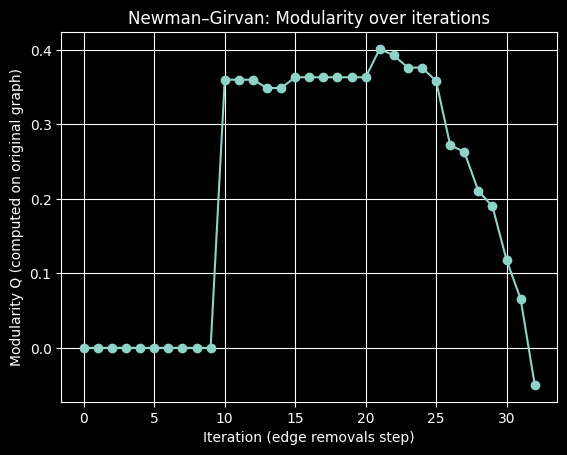

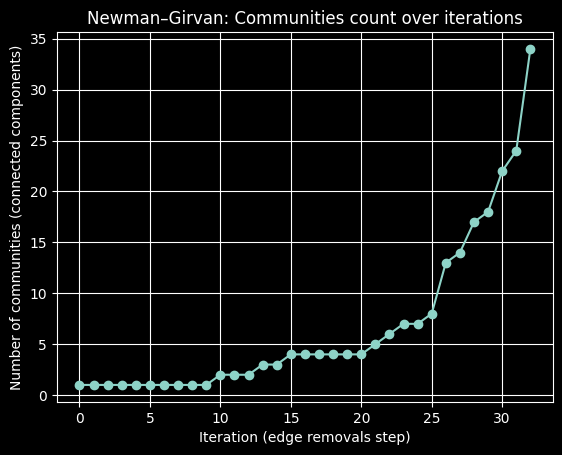

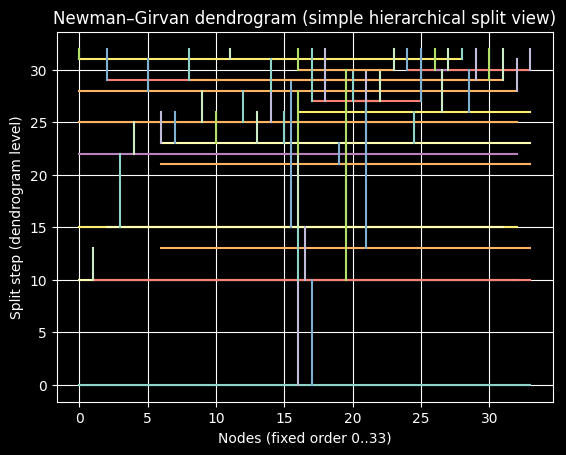

In [18]:
# -----------------------------
# Q5: Newman–Girvan (Girvan–Newman) on Zachary's Karate Club
# Dataset path: Data Sets\Basic\Zachary's karate club
# -----------------------------

# ---- 1) Load the Karate Club graph ----
# We'll try to load from your folder. If no edge file is found, we fall back to NetworkX built-in graph.
base_dir = Path(r"Data Sets/Basic/Zachary's karate club")

def try_load_karate_from_folder(folder: Path) -> nx.Graph | None:
    """
    Attempts to load an edge list / graph file from the given folder.
    Supports common formats:
      - edgelist-like: .txt .csv .tsv .edgelist
      - gml: .gml
    Returns None if nothing is found.
    """
    if not folder.exists():
        return None

    # Try common graph formats first
    gmls = list(folder.glob("*.gml"))
    if gmls:
        return nx.read_gml(gmls[0])

    # Try common edge list extensions
    candidates = []
    for ext in ("*.edgelist", "*.txt", "*.csv", "*.tsv"):
        candidates.extend(folder.glob(ext))

    if not candidates:
        return None

    # Pick the first candidate; if it's CSV/TSV, we guess delimiter; else treat as whitespace edge list.
    f = candidates[0]
    suffix = f.suffix.lower()

    if suffix in [".csv", ".tsv"]:
        sep = "," if suffix == ".csv" else "\t"
        df = pd.read_csv(f, sep=sep, header=None, comment="#")
        if df.shape[1] < 2:
            return None
        u = df.iloc[:, 0].astype(str)
        v = df.iloc[:, 1].astype(str)
        G = nx.Graph()
        G.add_edges_from(zip(u, v))
        return G

    # Default: whitespace edge list
    G = nx.read_edgelist(f, nodetype=int)
    return G

G = try_load_karate_from_folder(base_dir)
loaded_from = "folder"

if G is None:
    G = nx.karate_club_graph()
    loaded_from = "networkx_builtin"

# Ensure undirected simple graph
G = nx.Graph(G)
G.remove_edges_from(nx.selfloop_edges(G))

print("Loaded Karate Club graph from:", loaded_from)
print("Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges(), "| Directed?", G.is_directed())

# ---- 2) Edge betweenness centrality (undirected) - Brandes-style implementation ----
def edge_betweenness_undirected(G: nx.Graph) -> dict:
    """
    Compute edge betweenness centrality for an undirected, unweighted graph.
    Implementation based on Brandes algorithm idea, simplified for small graphs.
    Returns: dict with keys as (u,v) where u < v, values as betweenness score.
    """
    # Initialize betweenness for each edge to 0
    eb = {tuple(sorted(e)): 0.0 for e in G.edges()}

    for s in G.nodes():
        # BFS structures
        stack = []
        pred = {v: [] for v in G.nodes()}          # predecessors on shortest paths
        sigma = dict.fromkeys(G.nodes(), 0.0)      # number of shortest paths from s to v
        dist = dict.fromkeys(G.nodes(), -1)        # distance from s to v

        sigma[s] = 1.0
        dist[s] = 0

        # BFS queue
        from collections import deque
        Q = deque([s])

        while Q:
            v = Q.popleft()
            stack.append(v)
            for w in G.neighbors(v):
                # Found w for the first time?
                if dist[w] < 0:
                    dist[w] = dist[v] + 1
                    Q.append(w)
                # Is (v,w) on a shortest path?
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)

        # Accumulation
        delta = dict.fromkeys(G.nodes(), 0.0)
        while stack:
            w = stack.pop()
            for v in pred[w]:
                if sigma[w] > 0:
                    c = (sigma[v] / sigma[w]) * (1.0 + delta[w])
                else:
                    c = 0.0
                e = tuple(sorted((v, w)))
                eb[e] += c
                delta[v] += c

    # For undirected graphs, Brandes counts each pair twice => divide by 2
    for e in eb:
        eb[e] /= 2.0

    return eb

# ---- 3) Modularity for a partition (computed on the ORIGINAL graph) ----
def modularity_undirected(G_original: nx.Graph, communities: list[set]) -> float:
    """
    Modularity Q for undirected, unweighted graphs:
      Q = sum_c [ (l_c / m) - (d_c / (2m))^2 ]
    where:
      m = total edges in original graph
      l_c = number of edges inside community c (in original graph)
      d_c = sum of degrees of nodes in community c (in original graph)
    """
    m = G_original.number_of_edges()
    if m == 0:
        return 0.0

    deg = dict(G_original.degree())
    Q = 0.0

    for comm in communities:
        # sum of degrees in community
        d_c = sum(deg[v] for v in comm)

        # count internal edges in original graph
        # nx.subgraph(comm).number_of_edges() would work, but we keep it explicit for clarity
        sub = G_original.subgraph(comm)
        l_c = sub.number_of_edges()

        Q += (l_c / m) - (d_c / (2.0 * m)) ** 2

    return float(Q)

# ---- 4) Newman–Girvan main loop ----
G_work = G.copy()
G_original = G.copy()

partitions = []      # list of partitions (each partition is list[set])
modularities = []    # modularity at each step
num_comms = []       # number of communities at each step
removed_edges_log = []

# Record the initial partition (before removing anything)
current_partition = [set(c) for c in nx.connected_components(G_work)]
partitions.append(current_partition)
modularities.append(modularity_undirected(G_original, current_partition))
num_comms.append(len(current_partition))

max_steps = G.number_of_edges()  # worst case: remove all edges one by one

for step in range(1, max_steps + 1):
    if G_work.number_of_edges() == 0:
        break

    # 1) Compute edge betweenness on the current graph
    eb = edge_betweenness_undirected(G_work)

    # 2) Find max betweenness value and remove ALL edges that share that max (common Newman–Girvan variant)
    max_eb = max(eb.values())
    to_remove = [e for e, val in eb.items() if abs(val - max_eb) < 1e-12]

    G_work.remove_edges_from(to_remove)
    removed_edges_log.append((step, max_eb, to_remove))

    # 3) Compute new partition and modularity (on original graph)
    current_partition = [set(c) for c in nx.connected_components(G_work)]
    partitions.append(current_partition)
    modularities.append(modularity_undirected(G_original, current_partition))
    num_comms.append(len(current_partition))

# Best partition by modularity (ignore the trivial "all nodes in one community" if you want)
best_idx = int(np.argmax(modularities))
best_partition = partitions[best_idx]
best_Q = modularities[best_idx]

print("\n--- Results ---")
print("Total recorded steps:", len(partitions) - 1, "(excluding step 0)")
print("Best modularity Q:", best_Q)
print("Best step index:", best_idx, "| communities:", len(best_partition))
print("Community sizes (best):", sorted([len(c) for c in best_partition], reverse=True))

# Print best communities (nodes) - Karate graph is small, so it's okay
for i, comm in enumerate(sorted(best_partition, key=len, reverse=True), start=1):
    print(f"Community {i} (size={len(comm)}):", sorted(comm))

# ---- 5) Plot modularity and number of communities vs step ----
plt.figure()
plt.plot(range(len(modularities)), modularities, marker="o")
plt.xlabel("Iteration (edge removals step)")
plt.ylabel("Modularity Q (computed on original graph)")
plt.title("Newman–Girvan: Modularity over iterations")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(range(len(num_comms)), num_comms, marker="o")
plt.xlabel("Iteration (edge removals step)")
plt.ylabel("Number of communities (connected components)")
plt.title("Newman–Girvan: Communities count over iterations")
plt.grid(True)
plt.show()

# ---- 6) Simple dendrogram-like plot (based on split events) ----
# We build a split-tree from partitions. Each time a previous component splits into multiple components,
# we record a parent -> children relationship at that step.

# Fix a consistent node order for x-axis
node_order = sorted(G_original.nodes())
xpos = {v: i for i, v in enumerate(node_order)}

def as_fset_list(part):
    return [frozenset(c) for c in part]

parts_f = [as_fset_list(p) for p in partitions]

# Root cluster is all nodes
root = frozenset(node_order)

# Track when each cluster first appears
cluster_birth = {root: 0}
# Track parent links
parent_of = {}
# Track children links
children_of = {}

prev_clusters = [root]

for t in range(1, len(parts_f)):
    curr_clusters = parts_f[t]

    # For each previous cluster, see how it breaks in current partition
    for pc in prev_clusters:
        kids = [cc for cc in curr_clusters if cc.issubset(pc)]
        if len(kids) >= 2:
            # pc split at step t into kids
            children_of[pc] = kids
            for cc in kids:
                if cc not in cluster_birth:
                    cluster_birth[cc] = t
                parent_of[cc] = pc

    prev_clusters = curr_clusters

# Helper: cluster center on x-axis
def cluster_span(c):
    xs = [xpos[v] for v in c]
    return min(xs), max(xs), (min(xs) + max(xs)) / 2.0

# Plot
plt.figure()
# Draw clusters as horizontal segments at their "birth" step
for c, birth in cluster_birth.items():
    x0, x1, xc = cluster_span(c)
    plt.plot([x0, x1], [birth, birth])  # horizontal segment
    # connect to parent (vertical line)
    if c in parent_of:
        p = parent_of[c]
        _, _, pc = cluster_span(p)
        plt.plot([xc, xc], [birth, cluster_birth[p]])  # vertical connector (child to parent)

plt.xlabel("Nodes (fixed order 0..33)")
plt.ylabel("Split step (dendrogram level)")
plt.title("Newman–Girvan dendrogram (simple hierarchical split view)")
plt.grid(True)
plt.show()


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<ul>
  <li>
    <b>جدول/چاپ جوامع نهایی:</b> در کد، افرازی که بیشترین <span dir="ltr">Modularity</span> را دارد پیدا می‌شود و اعضای هر جامعه (و اندازه‌ی آن) چاپ می‌شود.
  </li>
  <li>
    <b>نمودار ماژولاریتی:</b> نمودار <span dir="ltr">Q</span> بر حسب شماره‌ی تکرار (حذف یال‌ها) نشان می‌دهد در چه مرحله‌ای بهترین تفکیک ساختاری به‌دست آمده است.
    معمولاً جواب نهایی را همان مرحله‌ای در نظر می‌گیریم که <span dir="ltr">Q</span> بیشینه است.
  </li>
  <li>
    <b>نمودار تعداد جامعه‌ها:</b> نشان می‌دهد با حذف یال‌های مرزی، گراف چگونه به چند مؤلفه (جامعه) شکسته می‌شود.
  </li>
  <li>
    <b>Dendrogram:</b> نمودار سلسله‌مراتبیِ شکستن جامعه‌هاست؛ هر چه در مراحل بالاتری قرار بگیریم (شماره‌ مرحله بیشتر شود)، شکافتن ریزتر و جزئی‌تر می‌شود.
  </li>
</ul>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
نکته: چون شبکه‌ی <span dir="ltr">Karate Club</span> کوچک است، پیاده‌سازی صریحِ <span dir="ltr">Betweenness</span> یال و محاسبات مرتبط سریع اجرا می‌شود و برای گزارش‌نویسی نیز قابل مشاهده و بررسی است.
</p>

</div>


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">

<h2>تحلیل صحت خروجی‌ها</h2>

<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
روند نمودارها و عددها کاملاً با منطق الگوریتم <span dir="ltr">Newman–Girvan</span> سازگار است:
تا زمانی که گراف هنوز به چند مؤلفه نشکسته، افراز مولفه‌های همبند فقط یک جامعه دارد و بنابراین <span dir="ltr">Modularity</span> تقریباً <span dir="ltr">0</span> می‌ماند؛
به محض این‌که با حذف یال‌های دارای <span dir="ltr">Betweenness</span> بالا اولین شکاف ایجاد می‌شود، تعداد جامعه‌ها افزایش می‌یابد و <span dir="ltr">Q</span> یک‌باره بالا می‌رود.
هم‌چنین انتخاب مرحله‌ی <span dir="ltr">best step</span> بر اساس بیشینه‌کردن <span dir="ltr">Q</span> ممکن است بیش از دو جامعه بدهد و حتی یک جامعه‌ی تک‌گرهی هم ایجاد کند (مثل گره <span dir="ltr">'10'</span>) که برای این الگوریتم کاملاً طبیعی است.
</p>

<h2>الگوریتم دقیقا چه کاری انجام می‌دهد؟</h2>

<ol>
  <li>
    روی گراف فعلی، برای هر یال مقدار <b><span dir="ltr">Betweenness</span> یال</b> (<span dir="ltr">Edge Betweenness</span>) را حساب می‌کنیم؛ یعنی تعداد (یا سهم) کوتاه‌ترین مسیرها بین تمام زوج‌گره‌هایی که کوتاه‌ترین مسیرشان از آن یال عبور می‌کنند.
  </li>
  <li>
    یال(های) با بیشترین <span dir="ltr">Betweenness</span> را حذف می‌کنیم (در کد شما همه‌ی یال‌هایی که دقیقا بیشینه هستند با هم حذف می‌شوند).
  </li>
  <li>
    بعد از هر حذف، <b>مؤلفه‌های همبند</b> گراف جدید را به‌عنوان جامعه‌های فعلی در نظر می‌گیریم.
  </li>
  <li>
    برای همین افراز، مقدار <b>ماژولاریتی</b> (<span dir="ltr">Q</span>) را روی <b>گراف اولیه</b> حساب می‌کنیم (تا معیار مقایسه ثابت بماند).
  </li>
  <li>
    در پایان، مرحله‌ای را که <span dir="ltr">Q</span> در آن بیشینه است به‌عنوان بهترین افراز انتخاب می‌کنیم.
  </li>
</ol>

<h2>هر خروجی چه چیزی را نشان می‌دهد؟</h2>

<h3>۱) متن <span dir="ltr">Results</span></h3>
<ul>
  <li><b>Total recorded steps:</b> تعداد دفعاتی که «محاسبه <span dir="ltr">Betweenness</span> → حذف یال → ثبت افراز» انجام شده است (نتوانستم جهت فلش‌ها رو درست کنم                                                                    :).</li>
  <li>
    <b>Best modularity Q و Best step index:</b>
    مرحله‌ای که بهترین افراز را داده است (در خروجی من <span dir="ltr">Q≈0.4013</span> در مرحله‌ی <span dir="ltr">21</span>).
  </li>
  <li>
    <b>Community sizes + members:</b>
    اندازه و اعضای هر جامعه در همان مرحله‌ی بهینه.
  </li>
</ul>

<h3>۲) نمودار <span dir="ltr">Modularity over iterations</span></h3>
<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
این نمودار نشان می‌دهد با حذف تدریجی یال‌های مرزی، کیفیت افرازها (طبق معیار <span dir="ltr">Q</span>) چگونه تغییر می‌کند.
این‌که تا حدود مرحله‌ی ۹ مقدار نزدیک صفر است کاملاً منطقی است چون هنوز گراف فقط یک مؤلفه دارد (یک جامعه ⇒ <span dir="ltr">Q≈0</span>).
سپس با اولین شکاف، <span dir="ltr">Q</span> جهش می‌کند و معمولاً تا یک نقطه بهینه بالا می‌رود و بعد با خرد شدن بیش از حد شبکه افت می‌کند.
</p>

<h3>۳) نمودار <span dir="ltr">Communities count over iterations</span></h3>
<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
این نمودار تعداد «جامعه‌ها» را که در این پیاده‌سازی همان تعداد مؤلفه‌های همبند است، در هر مرحله نشان می‌دهد.
رفتار افزایشی آن طبیعی است: هرچه یال‌ها با <span dir="ltr">Betweenness</span> بالاتر بیشتری حذف شوند، شبکه بیشتر تکه‌تکه می‌شود تا در نهایت ممکن است به تعداد زیادی مؤلفه (حتی تک‌گره‌ای) برسد.
</p>

<h3>۴) نمودار <span dir="ltr">Dendrogram</span></h3>
<p>
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; unicode-bidi: isolate-override;">
دندروگرام نمایی سلسله‌مراتبی از روند شکافتن است:
هر خط افقی یک خوشه یا جامعه را در یک سطح (شماره مرحله) نشان می‌دهد و خطوط عمودی نشان می‌دهند آن خوشه از شکافتن کدام خوشه بزرگ‌تر به‌وجود آمده است.
به زبان ساده: این نمودار می‌گوید جامعه‌ها دقیقاً در چه مراحلی از هم جدا شده‌اند و شکافتن‌ها چگونه به‌صورت درختی رخ داده‌اند.
</p>

</div>
